In [110]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score, roc_curve
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
#Reading in Data
data = pd.read_csv("../../data/marketdata.csv")
print(len(data))

iso_data = data[['Vix', 'VIX_roll_10', 'VIX_roll_20', 'VIX_day_change', 'VIX_sd', 'SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_VIX_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg']]
y = data['market_crisis']
iso_data.head()

minority_class = (data['market_crisis']>0).sum()
contamination = minority_class/len(data)

print(contamination)

4701
0.09232078281216763


In [112]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(iso_data, y, test_size=0.20, shuffle=False, random_state=101)
X_test.head()


,Vix,VIX_roll_10,VIX_roll_20,VIX_day_change,VIX_sd,SPY_roll_10,SPY_roll_20,SPY_roll_60,SPY_day_return,SPY_5_day_return,SPY_20_day_return,QQQ_day_return,IWM_day_return,TLT_day_return,GLD_day_return,SPY_drawdown,QQQ_drawdown,IWM_drawdown,SPY_TLT_corr_20,SPY_TLT_corr_60,SPY_GLD_corr_20,SPY_VIX_corr_20,SPY_vol_ratio,QQQ_vol_ratio,IWM_vol_ratio,spy_above_avg
3760,54.459999,37.292999,26.5800,12.520000,11.226204,10.626002,17.599081,11.090190,-0.078094,-0.112783,-0.174503,-0.069465,-0.097230,0.027103,0.001650,-18.948395,-18.318002,-23.105051,-0.617172,-0.621861,-0.086103,-0.954756,1.911154,1.648671,1.853895,0
3761,47.299999,39.237999,28.1930,-7.160000,12.008487,10.557958,18.223857,11.747726,0.051745,-0.039368,-0.138222,0.054450,0.031221,-0.051258,-0.021101,-14.754387,-13.870379,-20.704305,-0.707321,-0.688597,-0.238458,-0.960845,1.592241,1.349005,1.673335,0
3762,53.900002,41.872000,30.1290,6.600002,13.071885,11.854552,19.578435,13.011680,-0.048748,-0.123058,-0.181650,-0.043555,-0.063602,-0.036798,-0.003560,-18.909977,-17.621735,-25.747655,-0.479608,-0.496216,-0.196400,-0.959599,1.390293,1.150247,1.495179,0
3763,75.470001,45.503000,33.2155,21.570000,15.822743,17.999323,22.880009,15.617074,-0.095677,-0.179693,-0.264685,-0.091692,-0.110502,0.006197,-0.039888,-26.668445,-25.175124,-33.952698,-0.412342,-0.444950,0.140089,-0.961715,1.950828,1.656720,1.882440,0
3764,57.830002,47.275000,35.3995,-17.639999,16.592721,18.842356,23.331433,16.735232,0.085486,-0.094601,-0.200973,0.084706,0.066982,-0.022603,-0.030516,-20.399608,-18.837035,-29.528690,-0.480709,-0.486105,-0.082883,-0.971379,1.534245,1.519039,1.465842,0


In [113]:
#Baseline ISO model without specified contamination 

iso_mod = IsolationForest(random_state=101)
iso_mod.fit(X_train)
iso_preds = iso_mod.predict(X_test)
results = np.where(iso_preds == -1, 1, 0)

print(classification_report(y_test, results))
print(iso_mod.get_params())


              precision    recall  f1-score   support

           0       0.96      0.53      0.69       834
           1       0.19      0.84      0.31       107

    accuracy                           0.57       941
   macro avg       0.58      0.69      0.50       941
weighted avg       0.88      0.57      0.64       941

{'bootstrap': False, 'contamination': 'auto', 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 100, 'n_jobs': None, 'random_state': 101, 'verbose': 0, 'warm_start': False}


In [114]:
#Baseline ISO model with specified contamination 

iso_mod = IsolationForest(random_state=101, contamination=0.09)
iso_mod.fit(X_train)
iso_preds = iso_mod.predict(X_test)
results = np.where(iso_preds == -1, 1, 0)

vals = iso_mod.decision_function(X_test)
anomaly_scores = -vals
auc = roc_auc_score(y_test, anomaly_scores)


print(iso_mod.get_params())
print(f'ROC-AUC: {auc}')
print(classification_report(y_test, results))


{'bootstrap': False, 'contamination': 0.09, 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 100, 'n_jobs': None, 'random_state': 101, 'verbose': 0, 'warm_start': False}
ROC-AUC: 0.7461507429570362
              precision    recall  f1-score   support

           0       0.95      0.57      0.71       834
           1       0.19      0.77      0.30       107

    accuracy                           0.59       941
   macro avg       0.57      0.67      0.51       941
weighted avg       0.86      0.59      0.67       941



In [115]:
#Model Optimization

#parms
contam_vals = [0.05, 0.07, 0.09, 0.11, 0.12]
n_est_vals = [50, 100, 200, 300]
max_samps = [125, 256, 'auto']
max_features = [0.5, 0.75, 1.0]

results = []

for c in contam_vals:
    for n in n_est_vals:
        for m in max_samps:
            for f in max_features:
                model = IsolationForest(random_state=101, contamination=c, n_estimators=n, max_samples=m, max_features=f)
                model.fit(X_train)
                model_preds = np.where(model.predict(X_test) == -1, 1, 0)
                vals = model.decision_function(X_test)
                a_scores = -vals

                f1 = f1_score(y_test, model_preds)
                auc = roc_auc_score(y_test, a_scores)

                results.append({
                    'contamination': c,
                    'estimators': n,
                    'samples': m,
                    'features': f,
                    'f1': f1,
                    'auc': auc
                })

optimized_df = pd.DataFrame(results)

print(optimized_df.sort_values('auc', ascending=False))


     contamination  estimators samples  features        f1       auc
64            0.07         300     125      0.75  0.321138  0.751765
136           0.11         300     125      0.75  0.296073  0.751765
172           0.12         300     125      0.75  0.282828  0.751765
100           0.09         300     125      0.75  0.315425  0.751765
28            0.05         300     125      0.75  0.319328  0.751765
..             ...         ...     ...       ...       ...       ...
73            0.09          50     125      0.75  0.260749  0.706605
37            0.07          50     125      0.75  0.263911  0.706605
109           0.11          50     125      0.75  0.249688  0.706605
1             0.05          50     125      0.75  0.275574  0.706605
145           0.12          50     125      0.75  0.244499  0.706605

[180 rows x 6 columns]


In [116]:
#Reduced Model Using known Important Features
red_data = data[['Vix', 'VIX_roll_20', 'SPY_drawdown', 'QQQ_drawdown', 'SPY_TLT_corr_60']]
redX_train, redX_test, red_y_train, red_y_test = train_test_split(red_data, y, test_size=0.20, shuffle=False, random_state=101)

contam_vals = [0.05, 0.07, 0.09, 0.11, 0.12]
n_est_vals = [50, 100, 200, 300]
max_samps = [125, 256, 'auto']
max_features = [0.5, 0.75, 1.0]

RedResults = []

for c in contam_vals:
    for n in n_est_vals:
        for m in max_samps:
            for f in max_features:
                model = IsolationForest(random_state=101, contamination=c, n_estimators=n, max_samples=m, max_features=f)
                model.fit(redX_train)
                model_preds = np.where(model.predict(redX_test) == -1, 1, 0)
                vals = model.decision_function(redX_test)
                a_scores = -vals

                f1 = f1_score(red_y_test, model_preds)
                auc = roc_auc_score(red_y_test, a_scores)

                RedResults.append({
                    'contamination': c,
                    'estimators': n,
                    'samples': m,
                    'features': f,
                    'f1': f1,
                    'auc': auc
                })

red_optimized_df = pd.DataFrame(RedResults)

print(red_optimized_df.sort_values('auc', ascending=False))

     contamination  estimators samples  features        f1       auc
9             0.05         100     125      0.50  0.268156  0.698189
45            0.07         100     125      0.50  0.302405  0.698189
81            0.09         100     125      0.50  0.286501  0.698189
117           0.11         100     125      0.50  0.286996  0.698189
153           0.12         100     125      0.50  0.285714  0.698189
..             ...         ...     ...       ...       ...       ...
112           0.11          50     256      0.75  0.229299  0.634102
115           0.11          50    auto      0.75  0.229299  0.634102
40            0.07          50     256      0.75  0.256545  0.634102
43            0.07          50    auto      0.75  0.256545  0.634102
76            0.09          50     256      0.75  0.237762  0.634102

[180 rows x 6 columns]


In [117]:
#Optimal Model
optimal_model = IsolationForest(contamination=0.07, n_estimators=300, max_samples=125, max_features=0.75, random_state=101)
optimal_model.fit(X_train)
opt_preds = optimal_model.predict(X_test)
opt_results = np.where(opt_preds == -1, 1, 0)

opt_vals = optimal_model.decision_function(X_test)
opt_anomaly_scores = -opt_vals
opt_auc = roc_auc_score(y_test, opt_anomaly_scores)

print(f'ROC-AUC: {opt_auc}')
print(classification_report(y_test, opt_results))


ROC-AUC: 0.7517649431856384
              precision    recall  f1-score   support

           0       0.95      0.63      0.76       834
           1       0.21      0.74      0.32       107

    accuracy                           0.65       941
   macro avg       0.58      0.69      0.54       941
weighted avg       0.86      0.65      0.71       941



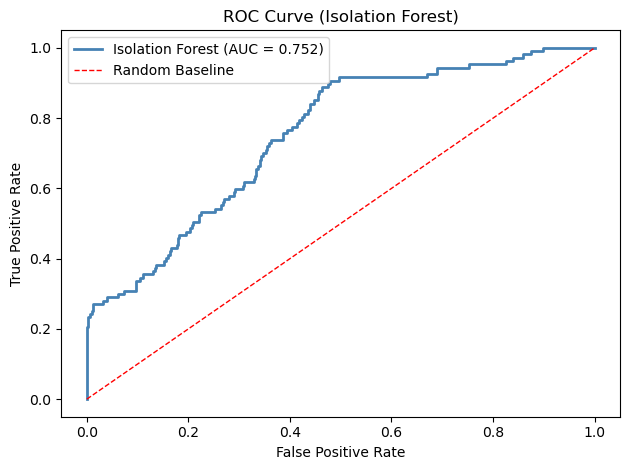

In [122]:
fpr, tpr, thresholds = roc_curve(y_test, opt_anomaly_scores)

plt.figure()
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Isolation Forest (AUC = {opt_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Isolation Forest)')
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/IF_ML/ROC_Curve.png")
plt.show()

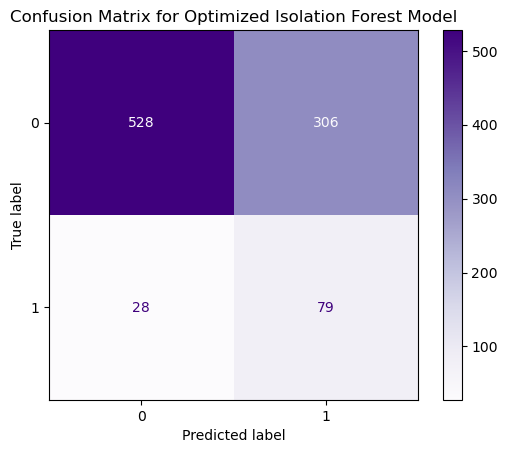

In [119]:

conf = confusion_matrix(y_test, opt_results)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=conf)
conf_plot.plot(cmap="Purples")
plt.title("Confusion Matrix for Optimized Isolation Forest Model")
plt.savefig("../visualizations/IF_ML/opt_if.png")
plt.show()

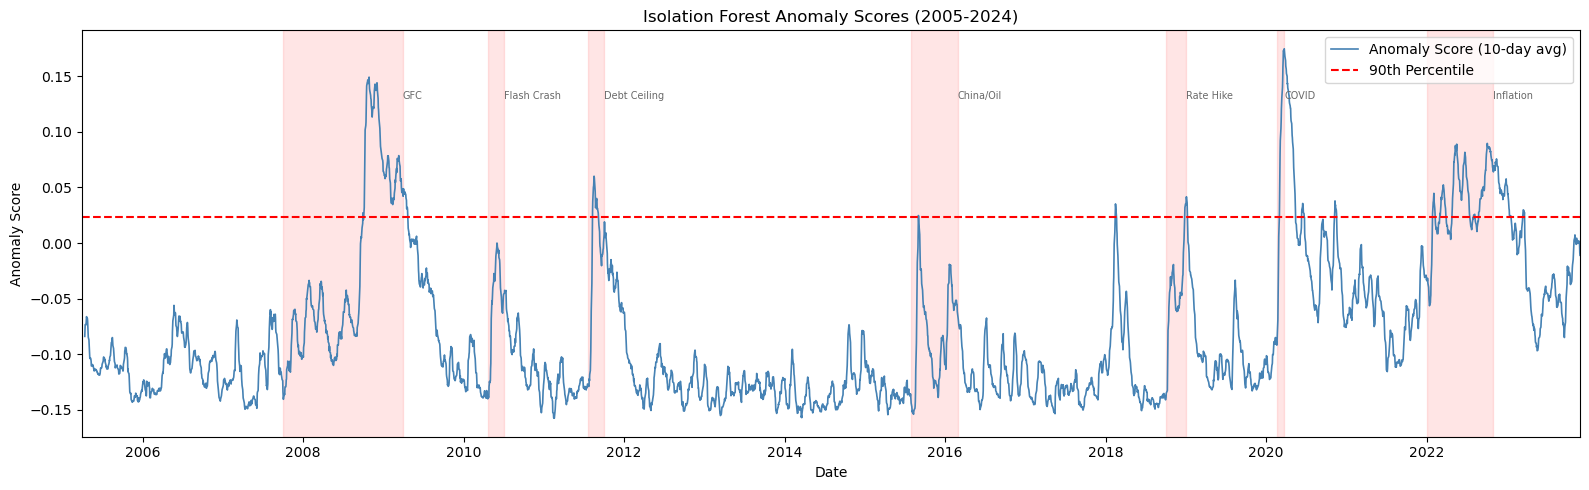

In [120]:
data['Date'] = pd.to_datetime(data['Date'])

crisis_periods = [
    ("2007-10-01", "2009-03-31", "GFC"),
    ("2010-04-23", "2010-07-02", "Flash Crash"),
    ("2011-07-22", "2011-10-03", "Debt Ceiling"),
    ("2015-08-01", "2016-02-29", "China/Oil"),
    ("2018-10-01", "2018-12-31", "Rate Hike"),
    ("2020-02-19", "2020-03-23", "COVID"),
    ("2022-01-01", "2022-10-31", "Inflation"),
]

all_scores = -optimal_model.decision_function(iso_data)
all_dates = data['Date'].reset_index(drop=True)
smoothed = pd.Series(all_scores).reset_index(drop=True).rolling(window=10).mean()

plt.figure(figsize=(16, 5))
plt.plot(all_dates, smoothed, color='steelblue', linewidth=1.2, label='Anomaly Score (10-day avg)')
plt.axhline(y=np.percentile(all_scores, 90), color='red', linestyle='--', label='90th Percentile')

for start, end, label in crisis_periods:
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color='red')
    plt.text(pd.Timestamp(end), 0.13, label, fontsize=7, color='dimgray')

plt.xlim(all_dates.min(), all_dates.max())
plt.xlabel('Date')
plt.ylabel('Anomaly Score')
plt.title('Isolation Forest Anomaly Scores (2005-2024)')
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/IF_ML/anomalygraph.png")
plt.show()